# Model Training – Chronological Split

Loads the chronologically split train/val data, trains a lightweight binary classifier,  
and evaluates on the honest validation set.

In [14]:
import numpy as np, pickle, os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import load_npz
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

sns.set_style("whitegrid")

## 1. Load data

In [15]:
X_train = load_npz('../data/processed/X_train.npz').toarray()
X_val   = load_npz('../data/processed/X_val.npz').toarray()
y_train = np.load('../data/processed/y_train.npy')
y_val   = np.load('../data/processed/y_val.npy')

with open('../artifacts/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
n_classes = len(le.classes_)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Classes: {le.classes_}")

Train: 972706, Val: 243178, Classes: ['DoS' 'normal']


## 2. Class weights

In [16]:
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(class_weights))
print("Class weights:", cw_dict)

Class weights: {0: np.float64(0.6089216137982151), 1: np.float64(2.7952285711001528)}


## 3. Model architecture

In [17]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │         1,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,258 (8.82 KB)

 Trainable params: 2,258 (8.82 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train with early stopping on validation set

In [21]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10, batch_size=32,
    class_weight=cw_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
30398/30398 ━━━━━━━━━━━━━━━━━━━━ 65s 2ms/step - accuracy: 0.9967 - loss: 0.0286 - val_accuracy: 0.9670 - val_loss: 0.1873
Epoch 2/10
30398/30398 ━━━━━━━━━━━━━━━━━━━━ 76s 3ms/step - accuracy: 0.9967 - loss: 0.0332 - val_accuracy: 0.9669 - val_loss: 0.1795
Epoch 3/10
30398/30398 ━━━━━━━━━━━━━━━━━━━━ 73s 2ms/step - accuracy: 0.9967 - loss: 0.0288 - val_accuracy: 0.9670 - val_loss: 0.2192
Epoch 4/10
30398/30398 ━━━━━━━━━━━━━━━━━━━━ 67s 2ms/step - accuracy: 0.9967 - loss: 0.0296 - val_accuracy: 0.9669 - val_loss: 0.1805
Epoch 5/10
30398/30398 ━━━━━━━━━━━━━━━━━━━━ 63s 2ms/step - accuracy: 0.9967 - loss: 0.0283 - val_accuracy: 0.9669 - val_loss: 0.2067
Epoch 6/10
30398/30398 ━━━━━━━━━━━━━━━━━━━━ 61s 2ms/step - accuracy: 0.9967 - loss: 0.0326 - val_accuracy: 0.9669 - val_loss: 0.1773
Epoch 7/10
30398/30398 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - accuracy: 0.9967 - loss: 0.0268 - val_accuracy: 0.9669 - val_loss: 0.1688
Epoch 8/10
30398/30398 ━━━━━━━━━━━━━━━━━━━━ 63s 2ms/step - accuracy: 

## 5. Learning curves & validation accuracy

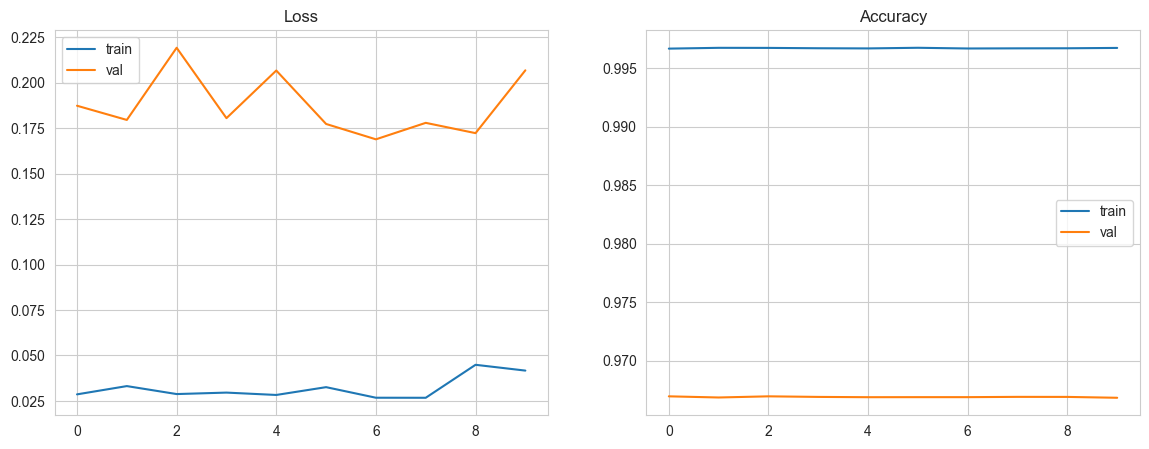

Honest validation accuracy: 0.9669


In [22]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.plot(history.history['loss'], label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(history.history['accuracy'], label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.set_title('Accuracy'); ax2.legend()
plt.show()

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Honest validation accuracy: {val_acc:.4f}")

## 6. Save model

In [23]:
os.makedirs('../artifacts/models', exist_ok=True)
model.save('../artifacts/models/best_model.keras')
print("✅ Saved best_model.keras")

✅ Saved best_model.keras
